# (12) DAVIS: play, understand

host = ```any```, device = ```cuda:1```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## load CelebA data

In [27]:
from PIL import Image


root = '/home/hadi/Datasets/DAVIS'
print(sorted(os.listdir(root)))

['Annotations_unsupervised', 'ImageSets', 'JPEGImages', 'README.md', 'SOURCES.md']

In [45]:
jpeg_imgs_dir = pjoin(root, 'JPEGImages', '480p')

for item in sorted(os.listdir(jpeg_imgs_dir), key=alphanum_sort_key):
    files = sorted(os.listdir(pjoin(jpeg_imgs_dir, item)), key=alphanum_sort_key)
    video = []
    for f in files:
        img = Image.open(pjoin(jpeg_imgs_dir, item, f))
        video.append(np.array(img))
    video = np.stack(video, axis=0)
    break

In [46]:
video.shape

(82, 480, 854, 3)

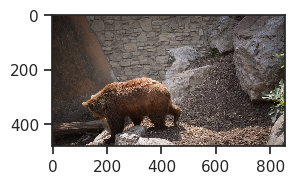

In [53]:
imshow(video[40])

In [21]:
sorted(os.listdir(jpeg_imgs_dir), key=alphanum_sort_key)

['bear',
 'bike-packing',
 'blackswan',
 'bmx-bumps',
 'bmx-trees',
 'boat',
 'boxing-fisheye',
 'breakdance',
 'breakdance-flare',
 'bus',
 'camel',
 'car-roundabout',
 'car-shadow',
 'car-turn',
 'cat-girl',
 'classic-car',
 'color-run',
 'cows',
 'crossing',
 'dance-jump',
 'dance-twirl',
 'dancing',
 'disc-jockey',
 'dog',
 'dog-agility',
 'dog-gooses',
 'dogs-jump',
 'dogs-scale',
 'drift-chicane',
 'drift-straight',
 'drift-turn',
 'drone',
 'elephant',
 'flamingo',
 'goat',
 'gold-fish',
 'hike',
 'hockey',
 'horsejump-high',
 'horsejump-low',
 'india',
 'judo',
 'kid-football',
 'kite-surf',
 'kite-walk',
 'koala',
 'lab-coat',
 'lady-running',
 'libby',
 'lindy-hop',
 'loading',
 'longboard',
 'lucia',
 'mallard-fly',
 'mallard-water',
 'mbike-trick',
 'miami-surf',
 'motocross-bumps',
 'motocross-jump',
 'motorbike',
 'night-race',
 'paragliding',
 'paragliding-launch',
 'parkour',
 'pigs',
 'pigs-duplicate',
 'planes-water',
 'rallye',
 'rhino',
 'rollerblade',
 'schoolgirls

In [ ]:
trn_vld_split_dir = pjoin(root, 'ImageSets', '2017')

## trn/vld sets

In [7]:
trn_vld_split_dir = pjoin(root, 'ImageSets', '2017')
os.listdir(trn_vld_split_dir)

['val.txt', 'train.txt']

In [14]:
with open(pjoin(trn_vld_split_dir, 'val.txt'), 'r') as f:
    vld_set = [e.replace('\n', '') for e in f.readlines()]
    
with open(pjoin(trn_vld_split_dir, 'train.txt'), 'r') as f:
    trn_set = [e.replace('\n', '') for e in f.readlines()]
    
len(trn_set), len(vld_set)

(60, 30)